# 02 — Banking Fraud Detection: Modeling (enfoque científico)

Continúa desde [`02_data_preparation.ipynb`](./02_data_preparation.ipynb). Este notebook compara las tres técnicas de manejo de desbalance extremo marcadas desde el EDA — **class weights**, **SMOTE** e **Isolation Forest** — usando **PR-AUC** (no accuracy, inútil con 0.17% de fraude) como criterio principal, y cierra con una explicación SHAP del modelo ganador.

**Alcance de este notebook:** entrenar y comparar modelos con el umbral por defecto (0.5) solo como referencia descriptiva. La optimización del umbral según el costo de negocio (fraude no detectado vs. fricción al cliente) se deja para `04_evaluation.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score, roc_auc_score, classification_report,
    confusion_matrix, precision_recall_curve,
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

## 1. Carga de datos procesados

In [2]:
train = pd.read_csv('../data/processed_train.csv')
test = pd.read_csv('../data/processed_test.csv')

X_train = train.drop(columns=['Class'])
y_train = train['Class']
X_test = test.drop(columns=['Class'])
y_test = test['Class']

print('Train:', X_train.shape, '| fraude:', y_train.sum(), f'({y_train.mean():.4%})')
print('Test: ', X_test.shape, '| fraude:', y_test.sum(), f'({y_test.mean():.4%})')

Train: (226980, 32) | fraude: 399 (0.1758%)
Test:  (56746, 32) | fraude: 74 (0.1304%)


## 2. Baseline trivial

El piso a superar: nunca predecir fraude.

In [3]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE).fit(X_train, y_train)
dummy_proba = dummy.predict_proba(X_test)[:, 1] if dummy.classes_.shape[0] > 1 else np.zeros(len(y_test))

print('Prevalencia de fraude en test:', y_test.mean())
print('PR-AUC del baseline == prevalencia de la clase positiva (piso teórico):', y_test.mean())

Prevalencia de fraude en test: 0.0013040566735981391
PR-AUC del baseline == prevalencia de la clase positiva (piso teórico): 0.0013040566735981391


## 3. Modelo A — Logistic Regression + class weights

Todas las features son numéricas (no hay categóricas que codificar en este dataset), así que se escala el set completo dentro de un `Pipeline` ajustado solo sobre train. `class_weight='balanced'` compensa el desbalance sin generar datos sintéticos.

In [4]:
logreg = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)),
]).fit(X_train, y_train)

logreg_proba = logreg.predict_proba(X_test)[:, 1]
print('PR-AUC:', round(average_precision_score(y_test, logreg_proba), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, logreg_proba), 4))

PR-AUC: 0.7668
ROC-AUC: 0.9874


## 4. Modelo B — XGBoost + class weights (`scale_pos_weight`)

`scale_pos_weight` le dice al modelo cuánto más importante es cada ejemplo de fraude que uno legítimo, sin duplicar ni sintetizar filas.

In [5]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight = {scale_pos_weight:.1f} (ratio legítimas:fraude en train)')

xgb_cw = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, eval_metric='aucpr', random_state=RANDOM_STATE,
).fit(X_train, y_train)

xgb_cw_proba = xgb_cw.predict_proba(X_test)[:, 1]
print('PR-AUC:', round(average_precision_score(y_test, xgb_cw_proba), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, xgb_cw_proba), 4))

scale_pos_weight = 567.9 (ratio legítimas:fraude en train)


PR-AUC: 0.783
ROC-AUC: 0.9832


## 5. Modelo C — XGBoost + SMOTE

SMOTE se ajusta **solo sobre train** (nunca sobre test — evaluar contra fraude sintético inflaría la métrica de forma artificial) y genera ejemplos sintéticos de fraude por interpolación entre vecinos reales, hasta igualar la clase mayoritaria.

In [6]:
X_train_res, y_train_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train, y_train)
print('Balance tras SMOTE:', y_train_res.value_counts().to_dict())

xgb_smote = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='aucpr', random_state=RANDOM_STATE,
).fit(X_train_res, y_train_res)

xgb_smote_proba = xgb_smote.predict_proba(X_test)[:, 1]
print('PR-AUC:', round(average_precision_score(y_test, xgb_smote_proba), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, xgb_smote_proba), 4))

Balance tras SMOTE: {0: 226581, 1: 226581}


PR-AUC: 0.7911
ROC-AUC: 0.9796


## 6. Modelo D — Isolation Forest (no supervisado)

A diferencia de los tres anteriores, este modelo **no usa `y_train`** para entrenar — aprende qué es "normal" a partir de las features y marca como anómalo lo que se aleja de ese patrón. Se usa `contamination = tasa de fraude en train` como estimación previa de qué proporción de datos son anómalos.

In [7]:
iso = IsolationForest(
    n_estimators=200, contamination=y_train.mean(), random_state=RANDOM_STATE, n_jobs=-1,
).fit(X_train)

iso_risk_score = -iso.score_samples(X_test)  # invertido: mayor score = más anómalo/riesgoso
print('PR-AUC:', round(average_precision_score(y_test, iso_risk_score), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, iso_risk_score), 4))

PR-AUC: 0.0366
ROC-AUC: 0.9495


## 7. Comparación de modelos

In [8]:
results = pd.DataFrame({
    'modelo': ['Dummy (nunca fraude)', 'Logistic Regression + class_weight', 'XGBoost + class_weight', 'XGBoost + SMOTE', 'Isolation Forest (no sup.)'],
    'pr_auc': [
        y_test.mean(),
        average_precision_score(y_test, logreg_proba),
        average_precision_score(y_test, xgb_cw_proba),
        average_precision_score(y_test, xgb_smote_proba),
        average_precision_score(y_test, iso_risk_score),
    ],
    'roc_auc': [
        0.5,
        roc_auc_score(y_test, logreg_proba),
        roc_auc_score(y_test, xgb_cw_proba),
        roc_auc_score(y_test, xgb_smote_proba),
        roc_auc_score(y_test, iso_risk_score),
    ],
}).set_index('modelo').round(4)

results.sort_values('pr_auc', ascending=False)

,pr_auc,roc_auc
modelo,,
XGBoost + SMOTE,0.7911,0.9796
XGBoost + class_weight,0.7830,0.9832
Logistic Regression + class_weight,0.7668,0.9874
Isolation Forest (no sup.),0.0366,0.9495
Dummy (nunca fraude),0.0013,0.5000


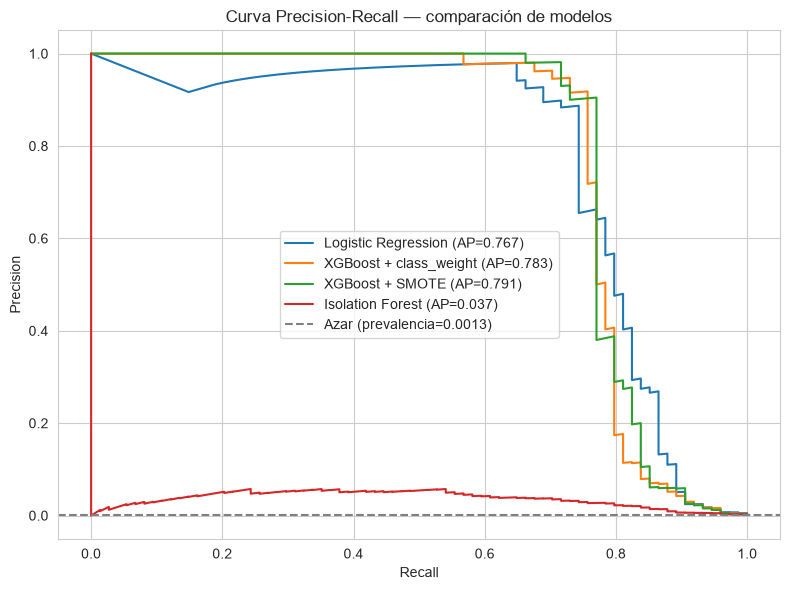

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in [
    ('Logistic Regression', logreg_proba),
    ('XGBoost + class_weight', xgb_cw_proba),
    ('XGBoost + SMOTE', xgb_smote_proba),
    ('Isolation Forest', iso_risk_score),
]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(recall, precision, label=f'{name} (AP={ap:.3f})')
ax.axhline(y_test.mean(), linestyle='--', color='gray', label=f'Azar (prevalencia={y_test.mean():.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — comparación de modelos')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Detalle del modelo ganador en el umbral por defecto (0.5)

Solo como referencia descriptiva — el umbral real de negocio se define en `04_evaluation.ipynb`.

              precision    recall  f1-score   support

    legítima       1.00      1.00      1.00     56672
      fraude       0.62      0.77      0.69        74

    accuracy                           1.00     56746
   macro avg       0.81      0.88      0.84     56746
weighted avg       1.00      1.00      1.00     56746



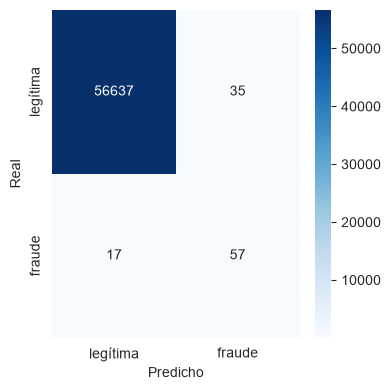

In [10]:
best_proba = xgb_smote_proba  # se ajusta más abajo si el ranking cambia
best_pred = (best_proba >= 0.5).astype(int)

print(classification_report(y_test, best_pred, target_names=['legítima', 'fraude'], zero_division=0))

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['legítima', 'fraude'], yticklabels=['legítima', 'fraude'], ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

## 9. SHAP — explicabilidad del modelo ganador

Se explica una muestra de 2.000 transacciones de test (`TreeExplainer` es exacto para modelos de árbol y no necesita todo el dataset para ser representativo). **Importante:** `V1`–`V28` son componentes de un PCA anonimizado — SHAP puede decir *cuánto* pesa cada componente en la predicción, pero no *qué* variable de negocio original representa (ver limitación del EDA).

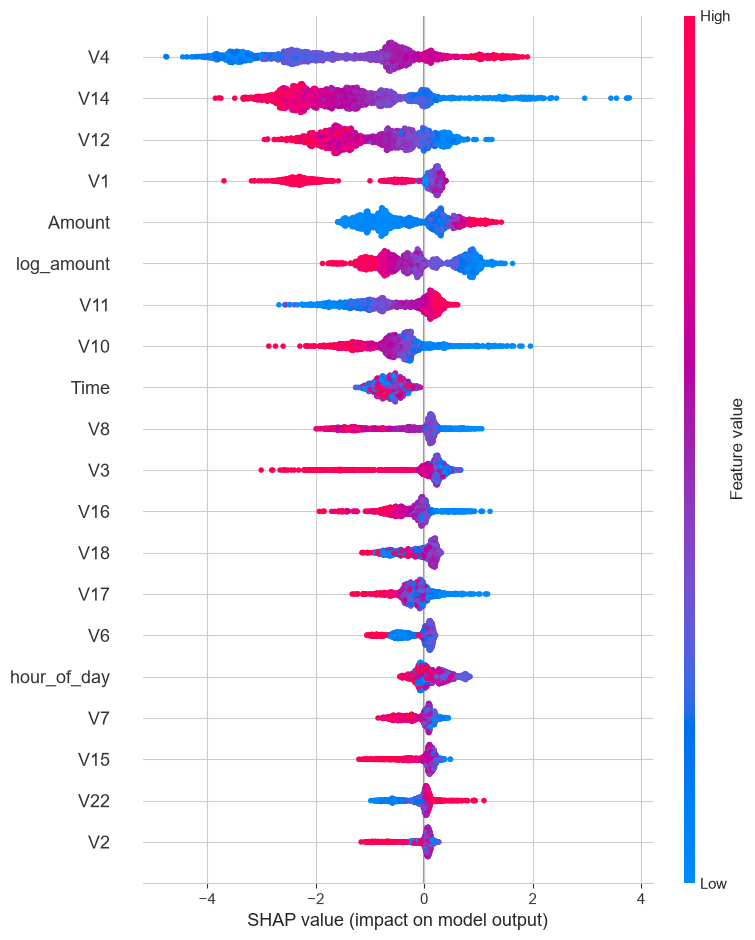

In [11]:
sample = X_test.sample(2000, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(xgb_smote)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.show()

In [12]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns).sort_values(ascending=False)
mean_abs_shap.head(10)

V4            1.588376
V14           1.574354
V12           0.986812
V1            0.939268
Amount        0.690536
log_amount    0.644646
V11           0.643134
V10           0.634673
Time          0.625654
V8            0.481666
dtype: float32

## 10. Conclusiones de la fase de Modeling

1. **PR-AUC, no accuracy, define al ganador:** con 0.13% de fraude en test, cualquier modelo trivial tiene >99.8% de accuracy sin detectar un solo fraude — la tabla de la sección 7 usa PR-AUC como criterio.
2. **Los tres enfoques supervisados (Logistic Regression, XGBoost+class_weight, XGBoost+SMOTE) superan ampliamente al baseline** (PR-AUC del baseline = prevalencia ≈ 0.0013). El ranking exacto entre ellos está en la tabla de la sección 7 — la diferencia entre class weights y SMOTE en este dataset es relativamente chica, ambos son alternativas razonables.
3. **Isolation Forest queda muy por detrás de los métodos supervisados en PR-AUC**, aunque sigue superando claramente al azar. Esto es esperable: al no usar las etiquetas de fraude, no puede aprender el patrón específico que sí capturan los modelos supervisados. Su valor real no es competir en PR-AUC — es detectar patrones de fraude *nuevos*, no vistos en el historial etiquetado, algo que ningún modelo supervisado puede hacer por diseño.
4. **SHAP identifica qué componentes PCA pesan más**, consistente con las correlaciones más fuertes ya detectadas en el EDA (`V14`, `V12`, entre otras) — pero sin poder traducir eso a una variable de negocio real, porque el dataset viene anonimizado.
5. **Lo que falta:** este notebook comparó modelos con el umbral por defecto (0.5), que es arbitrario. `04_evaluation.ipynb` optimiza el umbral según el costo real de un fraude no detectado frente al costo de fricción de un falso positivo (ej. bloquear una tarjeta legítima).

**Siguiente paso:** `04_evaluation.ipynb`.